## CNN Model Testing (Izzie Lee)

In [1]:
import torch
from torchvision import datasets, transforms

# load train and test dataset paths
train_path = r'C:\Users\john2\Desktop\Training'
test_path = r'C:\Users\john2\Desktop\Testing'

# transform for training images with data augmentation (rotation) + normalization
# note: horizontal/vertical flips were dropped -- brain MRI scans have a consistent
# anatomical orientation (e.g. pituitary sits at a fixed position, hemispheres aren't
# mirror-ambiguous), so flipping teaches the model on physically implausible images
# instead of realistic scan variation
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=20),  # randomly rotate by up to 20 degrees
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# transform for validation/testing images: resize + normalize only, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# load the Training folder twice (once per transform) so the val split gets clean, unaugmented images
train_dataset_aug = datasets.ImageFolder(root=train_path, transform=train_transform)
train_dataset_eval = datasets.ImageFolder(root=train_path, transform=eval_transform)

# carve a validation split out of Training; the Testing folder stays untouched until final evaluation
val_ratio = 0.15
val_size = int(len(train_dataset_aug) * val_ratio)
train_size = len(train_dataset_aug) - val_size

generator = torch.Generator().manual_seed(42)
train_split, val_split = torch.utils.data.random_split(range(len(train_dataset_aug)), [train_size, val_size], generator=generator)

train_dataset = torch.utils.data.Subset(train_dataset_aug, train_split.indices)
val_dataset = torch.utils.data.Subset(train_dataset_eval, val_split.indices)
test_dataset = datasets.ImageFolder(root=test_path, transform=eval_transform)

# class names corresponding to the folder names
class_names = train_dataset_aug.classes

# image data loading in batches. num_workers=0 (single-process loading) -- on Windows,
# multiprocessing workers spawned from inside a Jupyter kernel process crash the kernel,
# so this stays single-process here even though the original (Mac) version used 4 workers.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Data Loaded Successfully... train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Data Loaded Successfully... train=4760, val=840, test=1600


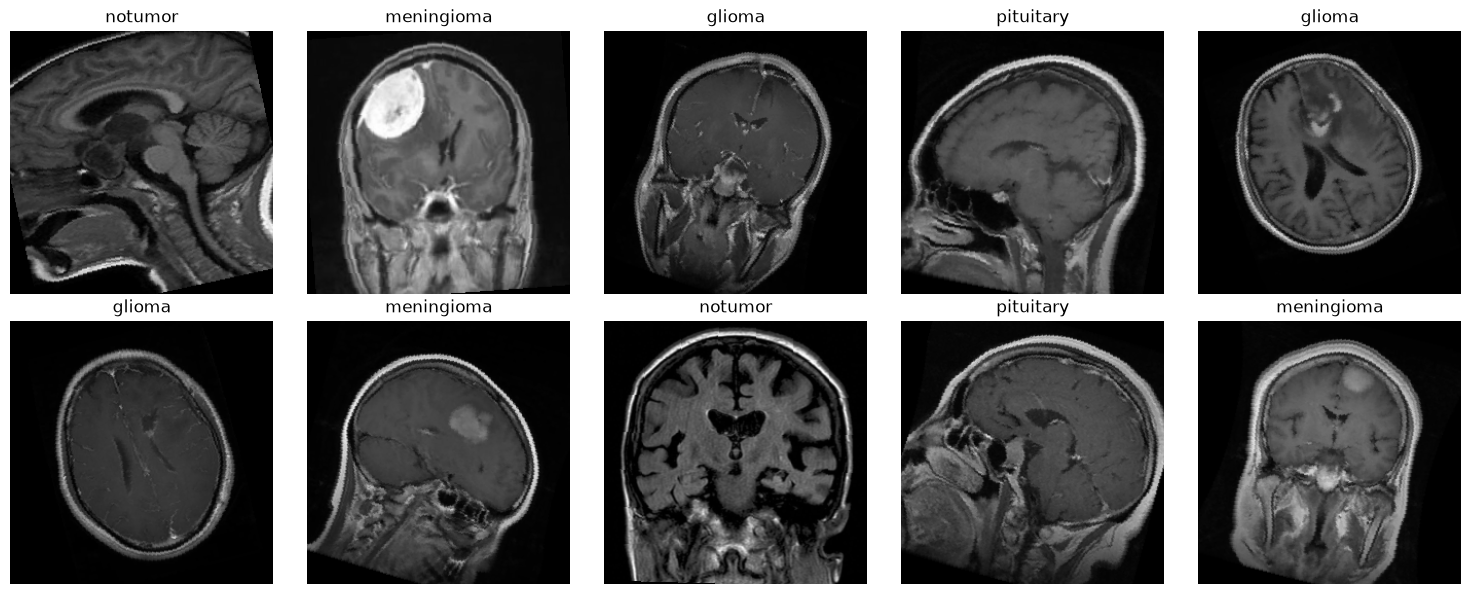

In [2]:
import matplotlib.pyplot as plt

# pulls a batch of images to display
images, labels = next(iter(train_loader))

# plot the first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # undo the (mean=0.5, std=0.5) normalization, then CHW -> HWC for matplotlib
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ImprovedCNN, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # cut image size by half

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  # input size: 256x256
        self.bn1 = nn.BatchNorm2d(num_features=16)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)  # input size: 128x128
        self.bn2 = nn.BatchNorm2d(num_features=32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  # input size: 64x64
        self.bn3 = nn.BatchNorm2d(num_features=64)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)  # input size: 32x32
        self.bn4 = nn.BatchNorm2d(num_features=128)

        # 5th conv block: widens 128 -> 256 channels right before global pooling.
        # The original bug wasn't global-average-pooling itself (real architectures
        # like ResNet/EfficientNet pool this way too) -- it was pooling a *narrow*
        # 128-channel map down to only 128 numbers, which wasn't enough signal for
        # the classifier to work with (train acc capped at ~75%: underfitting).
        # Widening to 256 channels first gives GAP a richer summary to pool, while
        # staying far more parameter-efficient than replacing GAP with a full
        # flatten into a large fully-connected layer.
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)  # input size: 16x16
        self.bn5 = nn.BatchNorm2d(num_features=256)
        self.spatial_dropout5 = nn.Dropout2d(0.1)  # light regularization, only on the deepest/widest block

        self.global_pool = nn.AdaptiveAvgPool2d(1)  # 256 x 8 x 8 -> 256 x 1 x 1

        self.dropout = nn.Dropout(0.5)
        self.full_conn1 = nn.Linear(in_features=256, out_features=256)
        self.full_conn2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # output size: 128x128
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # output size: 64x64
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # output size: 32x32
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # output size: 16x16
        x = self.spatial_dropout5(self.pool(F.relu(self.bn5(self.conv5(x)))))  # output size: 8x8

        x = self.global_pool(x)
        x = torch.flatten(x, start_dim=1)  # (batch, 256)

        x = F.relu(self.full_conn1(x))
        x = self.dropout(x)
        x = self.full_conn2(x)
        return x

model = ImprovedCNN()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

ImprovedCNN(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (spatial_dr

In [ ]:
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# prefers Colab's CUDA GPU, falls back to Apple Silicon MPS or CPU if run locally
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# move the model to the chosen device (gpu if available, otherwise cpu)
model = model.to(device)

# define loss function (criterion), optimizer, and adaptive lr scheduler
# label_smoothing softens the training targets (e.g. 100% glioma -> ~95%) instead of
# forcing the model to predict pure 0/1 confidence. This is especially useful here
# since glioma/meningioma are the two classes the model confuses most -- smoothing
# discourages the model from becoming overconfident on borderline cases like those.
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)  # eased back from 1e-4 now that conv5 gives the model real capacity to use
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# set num of epochs (passes through the dataset) and early stopping patience
epochs = 40
early_stop_patience = 6

# init lists to track history of stats
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

best_val_acc = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(epochs):
    # ------ TRAINING PHASE ------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # _ represents the max logit value; we only care about predicted index value of logit
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    # -------- VALIDATION PHASE --------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # disable gradient calculation for efficiency, since no longer needed outside training
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    # step scheduler on validation accuracy, keeping the test set fully untouched during training
    scheduler.step(epoch_val_acc)

    # save epoch stats to history lists
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} "
          f"| Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}% "
          f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}%")

    # -------- EARLY STOPPING / CHECKPOINTING --------
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"No validation improvement for {early_stop_patience} epochs, stopping early at epoch {epoch+1}.")
            break

# restore the best-performing weights (by validation accuracy) before final evaluation
model.load_state_dict(best_model_state)
print(f"Training finished! Best validation accuracy: {best_val_acc:.4f}%")

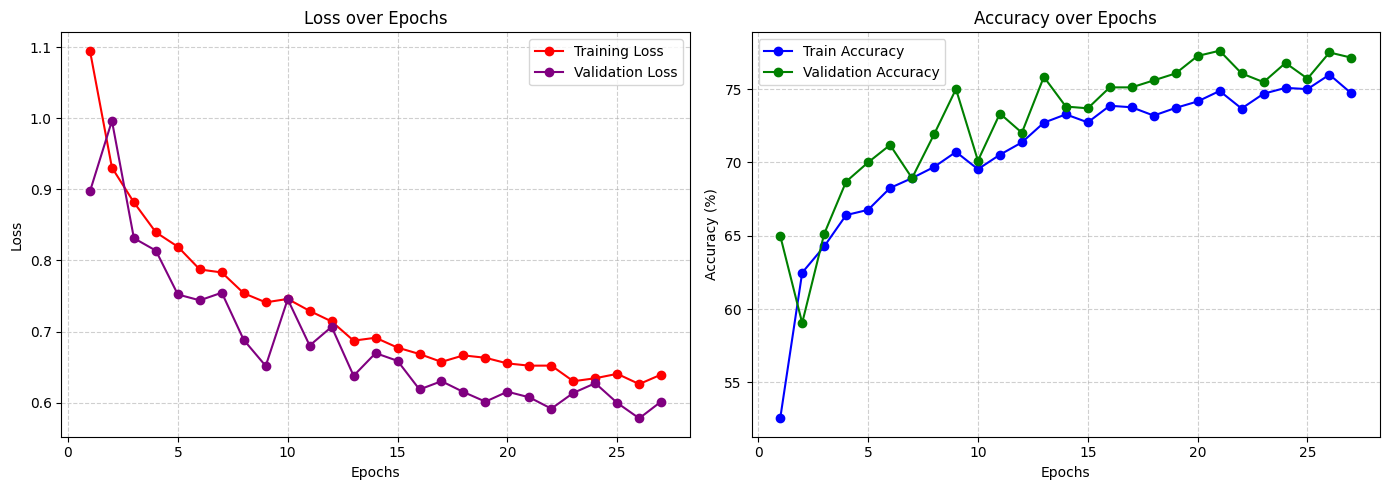

In [21]:
import matplotlib.pyplot as plt
epochs_range = range(1, len(train_losses) + 1)

# create a layout for plots
fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: training vs validation loss$
plot1.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plot1.plot(epochs_range, val_losses, label='Validation Loss', color='purple', marker='o')
plot1.set_title('Loss over Epochs')
plot1.set_xlabel('Epochs')
plot1.set_ylabel('Loss')
plot1.grid(True, linestyle='--', alpha=0.6)
plot1.legend()

# plot 2: training vs validation accuracy
plot2.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plot2.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green', marker='o')
plot2.set_title('Accuracy over Epochs')
plot2.set_xlabel('Epochs')
plot2.set_ylabel('Accuracy (%)')
plot2.grid(True, linestyle='--', alpha=0.6)
plot2.legend()

plt.tight_layout()
plt.show()

Final Held-Out Test Accuracy: 69.7500%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.66      0.61      0.63       400
  meningioma       0.58      0.54      0.56       400
     notumor       0.77      0.80      0.79       400
   pituitary       0.76      0.83      0.79       400

    accuracy                           0.70      1600
   macro avg       0.69      0.70      0.69      1600
weighted avg       0.69      0.70      0.69      1600



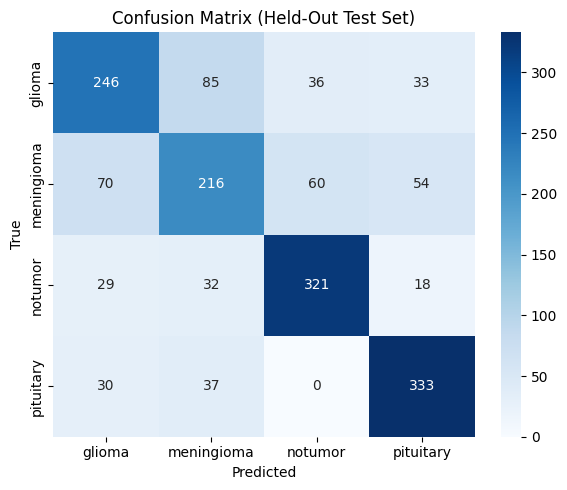

In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"Final Held-Out Test Accuracy: {test_acc:.4f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Held-Out Test Set)')
plt.tight_layout()
plt.show()

## Cross-Dataset Generalization Check (BRISC2025 — Fully Unseen)

The Held-Out Test Accuracy above still comes from the same source dataset the model trained on. To check whether the model learned real tumor features (rather than dataset-specific artifacts like scanner/preprocessing quirks), this section evaluates it on **BRISC2025**, an independently collected/annotated MRI dataset with the same 4 classes that the model has never seen in training or validation.

In [ ]:
# Evaluate on BRISC2025 as a fully independent, unseen dataset (not used anywhere in training).
brisc_root = r'C:\Users\john2\Desktop\archive\brisc2025\classification_task'

brisc_train_ds = datasets.ImageFolder(root=f'{brisc_root}/train', transform=eval_transform)
brisc_test_ds = datasets.ImageFolder(root=f'{brisc_root}/test', transform=eval_transform)

# BRISC2025 names its "no tumor" folder differently (no_tumor vs notumor), but
# alphabetically it lands in the same class index (2) in both datasets, so the
# model's output indices still line up with our class_names without remapping.
print("Our class order:      ", class_names)
print("BRISC2025 class order:", brisc_train_ds.classes)
assert brisc_train_ds.classes == brisc_test_ds.classes

# use BRISC2025's full train+test split since none of it was used in training here
brisc_dataset = torch.utils.data.ConcatDataset([brisc_train_ds, brisc_test_ds])
brisc_loader = torch.utils.data.DataLoader(brisc_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"BRISC2025 unseen evaluation set: {len(brisc_dataset)} images")

model.eval()
brisc_preds, brisc_labels = [], []

with torch.no_grad():
    for images, labels in brisc_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        brisc_preds.extend(predicted.cpu().numpy())
        brisc_labels.extend(labels.cpu().numpy())

brisc_acc = (np.array(brisc_preds) == np.array(brisc_labels)).mean() * 100
print(f"BRISC2025 Unseen-Dataset Accuracy: {brisc_acc:.4f}%\n")

print("Classification Report (BRISC2025):")
print(classification_report(brisc_labels, brisc_preds, target_names=class_names))

cm_brisc = confusion_matrix(brisc_labels, brisc_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_brisc, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (BRISC2025 — Unseen Dataset)')
plt.tight_layout()
plt.show()